In [1]:
import sys
import os
sys.path.append('../')

import pandas as pd
import pprint
from util.polymarket_client import PolymarketAPIClient
from util.data_processor import parse_timestamp
from trading_rules.position_data import Positions
from trading_rules.mean_reversal import MeanReversal
from trading_rules.market_data import MarketData
from util.backtester import perform_mean_reversal_backtest

In [2]:
SLUG = 'will-jesus-christ-return-in-2025'

In [3]:
client = PolymarketAPIClient()

In [4]:
market = client.get_price_history_by_outcome(SLUG, desired_outcome="No", interval="1h")

Will Jesus Christ return in 2025?
Not Will Jesus Christ return in 2025?
requested start and end: 2024-12-31 12:00:00+00:00 2025-12-31 12:00:00+00:00


In [5]:
market

,timestamp,open,high,low,close,volume,outcome_id,timestamp_formatted
0,1742511600000,0.9615,0.9615,0.9615,0.9615,0,4334699957357127908482970555095165722856012218...,2025-03-20 23:00:00+00:00
1,1742515200000,0.9660,0.9660,0.9660,0.9660,0,4334699957357127908482970555095165722856012218...,2025-03-21 00:00:00+00:00
2,1742518800000,0.9485,0.9485,0.9485,0.9485,0,4334699957357127908482970555095165722856012218...,2025-03-21 01:00:00+00:00
3,1742522400000,0.9520,0.9520,0.9520,0.9520,0,4334699957357127908482970555095165722856012218...,2025-03-21 02:00:00+00:00
4,1742526000000,0.9505,0.9505,0.9505,0.9505,0,4334699957357127908482970555095165722856012218...,2025-03-21 03:00:00+00:00
...,...,...,...,...,...,...,...,...
6840,1767164400000,0.9995,0.9995,0.9995,0.9995,0,4334699957357127908482970555095165722856012218...,2025-12-31 07:00:00+00:00
6841,1767168000000,0.9995,0.9995,0.9995,0.9995,0,4334699957357127908482970555095165722856012218...,2025-12-31 08:00:00+00:00
6842,1767171600000,0.9995,0.9995,0.9995,0.9995,0,4334699957357127908482970555095165722856012218...,2025-12-31 09:00:00+00:00
6843,1767175200000,0.9995,0.9995,0.9995,0.9995,0,4334699957357127908482970555095165722856012218...,2025-12-31 10:00:00+00:00


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly 
%matplotlib inline

In [7]:
market_data = MarketData(market)

In [8]:
market_data.df.describe()

,timestamp,open,high,low,close,volume
count,6.845000e+03,6845.000000,6845.000000,6845.000000,6845.000000,6845.0
mean,1.754838e+12,0.981118,0.981118,0.981118,0.981118,0.0
std,7.121209e+09,0.009904,0.009904,0.009904,0.009904,0.0
min,1.742512e+12,0.948500,0.948500,0.948500,0.948500,0.0
25%,1.748671e+12,0.972000,0.972000,0.972000,0.972000,0.0
50%,1.754834e+12,0.979500,0.979500,0.979500,0.979500,0.0
75%,1.760998e+12,0.990000,0.990000,0.990000,0.990000,0.0
max,1.767179e+12,0.999500,0.999500,0.999500,0.999500,0.0


In [9]:
# candle stick chart using plotly dash


In [10]:
import plotly.express as px

fig = px.line(
    market_data.df,
    x='timestamp_formatted',
    y='close',
    title=f'Close Price Over Time — {SLUG}',
    labels={'timestamp_formatted': 'Timestamp', 'close': 'Close Price'},
)
fig.update_layout(xaxis_title='Timestamp', yaxis_title='Close Price')
fig.show()

<Axes: xlabel='returns', ylabel='Count'>

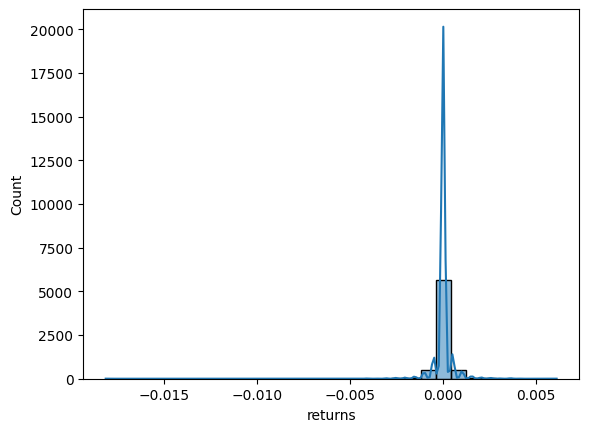

In [11]:
arith_return = market_data.get_returns()
sns.histplot(arith_return, bins=30, kde=True)

<Axes: xlabel='log_returns', ylabel='Count'>

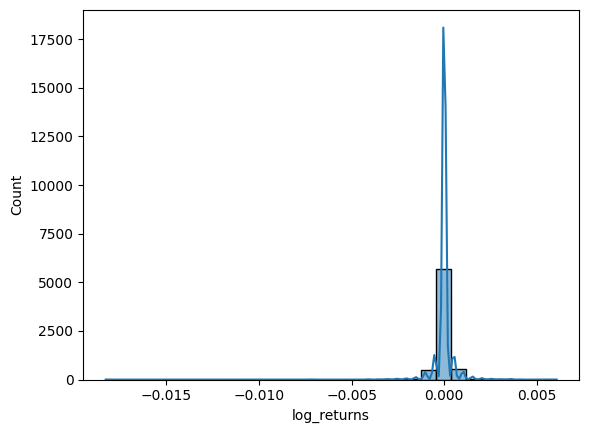

In [12]:
log_returns = market_data.get_log_returns()
sns.histplot(log_returns, bins=30, kde=True)